In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('shoreline_validation_results.csv')

# Display the first few rows and columns to understand the structure
print(df.head())
print(df.info())
print(df['experiment'].unique()) # Check for experiment identifiers if any

    experiment    site          direction       N       RMSE        MAE  \
0  exp1_bilstm  agrelo  oblique-rectified  313962  34.181205  20.866006   
1  exp1_bilstm  agrelo  rectified-oblique   50153  93.945139  58.144454   
2  exp1_bilstm  agrelo      oblique-truth  313962  31.937416  21.679001   
3  exp1_bilstm  agrelo      truth-oblique    2635  71.054881  37.422208   
4  exp1_bilstm  agrelo    rectified-truth   50153  38.236749  24.556023   

          Q3         SD  
0  28.750176  27.073362  
1  94.295375  73.790380  
2  32.312181  23.452531  
3  43.562236  60.413241  
4  33.330115  29.309860  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   experiment  324 non-null    object 
 1   site        324 non-null    object 
 2   direction   324 non-null    object 
 3   N           324 non-null    int64  
 4   RMSE        324 non-null    float64
 5

In [2]:
# Display columns to identify correct names
print(df.columns)
print(df.head())

Index(['experiment', 'site', 'direction', 'N', 'RMSE', 'MAE', 'Q3', 'SD'], dtype='object')
    experiment    site          direction       N       RMSE        MAE  \
0  exp1_bilstm  agrelo  oblique-rectified  313962  34.181205  20.866006   
1  exp1_bilstm  agrelo  rectified-oblique   50153  93.945139  58.144454   
2  exp1_bilstm  agrelo      oblique-truth  313962  31.937416  21.679001   
3  exp1_bilstm  agrelo      truth-oblique    2635  71.054881  37.422208   
4  exp1_bilstm  agrelo    rectified-truth   50153  38.236749  24.556023   

          Q3         SD  
0  28.750176  27.073362  
1  94.295375  73.790380  
2  32.312181  23.452531  
3  43.562236  60.413241  
4  33.330115  29.309860  


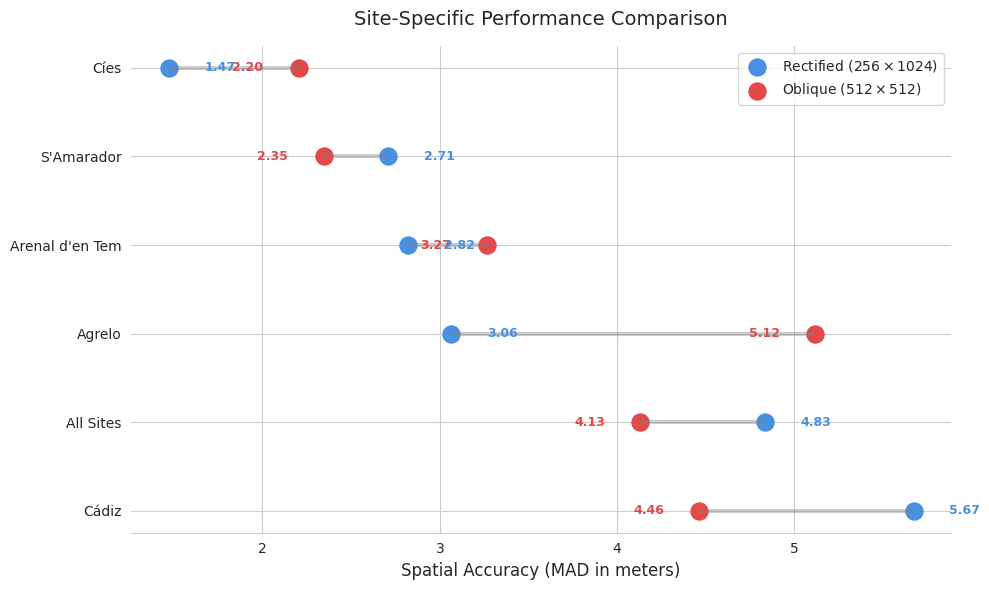

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('shoreline_validation_results.csv')

# Filter data
rect_filter = (df['experiment'] == 'exp3_deeplabv3_256x1024') & (df['direction'] == 'rectified-truth')
oblique_filter = (df['experiment'] == 'exp3_deeplabv3_512x512') & (df['direction'] == 'oblique-truth')

df_rect = df[rect_filter][['site', 'MAE']].rename(columns={'MAE': 'Rectified'})
df_oblique = df[oblique_filter][['site', 'MAE']].rename(columns={'MAE': 'Oblique'})

# Merge
df_plot = pd.merge(df_rect, df_oblique, on='site')

# Capitalize site names for better display
df_plot['Site_Label'] = df_plot['site'].str.replace('_', ' ').str.title()

# Fix site names manually for presentation quality
site_mapping = {
    'agrelo': 'Agrelo',
    'arenaldentem': "Arenal d'en Tem",
    'cadiz': 'Cádiz',
    'cies': 'Cíes',
    'samarador': "S'Amarador",
    'all': 'All Sites'
}
df_plot['Site_Label'] = df_plot['site'].map(site_mapping).fillna(df_plot['site'])

# Sort by Rectified error for visual order
df_plot = df_plot.sort_values('Rectified', ascending=False)

# Remove 'all' if present, based on previous context, though the user code didn't explicitly remove it in the snippet provided.
# However, usually 'all' or 'global' creates a mess in site-specific plots. Let's check if 'all' is in there.
if 'all' in df_plot['site'].values:
    df_plot = df_plot[df_plot['site'] != 'all']

# --- PLOTTING ---
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Define y positions
y_range = range(len(df_plot))

# Draw the line
ax.hlines(y=y_range, xmin=df_plot['Oblique'], xmax=df_plot['Rectified'],
          color='grey', alpha=0.4, linewidth=3)

# Draw points
# Rectified
ax.scatter(df_plot['Rectified'], y_range, color='#4A90E2', alpha=1, s=150, label='Rectified ($256 \\times 1024$)')
# Oblique
ax.scatter(df_plot['Oblique'], y_range, color='#E24A4A', alpha=1, s=150, label='Oblique ($512 \\times 512$)')

# Labels and Titles
ax.set_yticks(y_range)
ax.set_yticklabels(df_plot['Site_Label'])
ax.set_xlabel('Spatial Accuracy (MAD in meters)', fontsize=12)
ax.set_title('Site-Specific Performance Comparison', fontsize=14, pad=15)
ax.legend(loc='upper right')

# Remove borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Add values next to points
for idx, (i, row) in enumerate(df_plot.iterrows()):
    # Oblique Value - Manually offset x by subtracting a small value
    # Adjust offset based on data scale. Max value is around 9, min is 1.5. 0.2 seems reasonable.
    ax.text(row['Oblique'] - 0.2, idx, f"{row['Oblique']:.2f}",
            va='center', ha='right', color='#E24A4A', fontsize=9, fontweight='bold')
    
    # Rectified Value - Manually offset x by adding a small value
    ax.text(row['Rectified'] + 0.2, idx, f"{row['Rectified']:.2f}",
            va='center', ha='left', color='#4A90E2', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('dumbbell_plot_site_specific_corrected.png')
plt.show()

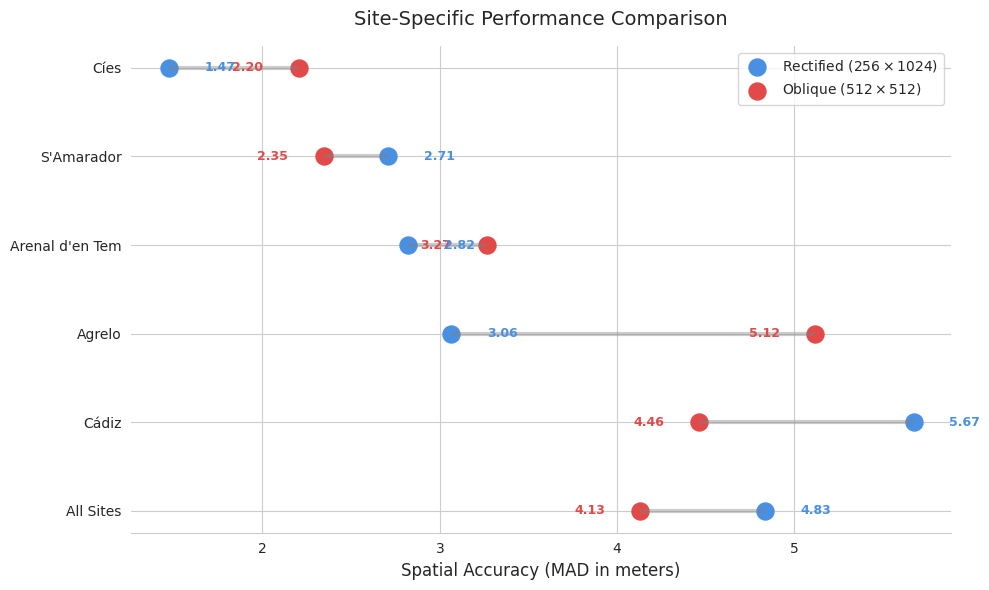

In [ ]:
df = pd.read_csv('shoreline_validation_results.csv')

rect_filter = (df['experiment'] == 'exp3_deeplabv3_256x1024') & (df['direction'] == 'rectified-truth')
oblique_filter = (df['experiment'] == 'exp3_deeplabv3_512x512') & (df['direction'] == 'oblique-truth')

df_rect = df[rect_filter][['site', 'MAE']].rename(columns={'MAE': 'Rectified'})
df_oblique = df[oblique_filter][['site', 'MAE']].rename(columns={'MAE': 'Oblique'})

df_plot = pd.merge(df_rect, df_oblique, on='site')

site_mapping = {
    'agrelo': 'Agrelo',
    'arenaldentem': "Arenal d'en Tem",
    'arenal_den_tem': "Arenal d'en Tem", # Per si de cas
    'cadiz': 'Cádiz',
    'cies': 'Cíes',
    'samarador': "S'Amarador",
    'all': 'All Sites'
}

df_plot['Site_Label'] = df_plot['site'].map(site_mapping).fillna(df_plot['site'].str.replace('_', ' ').str.title())

mask_all = df_plot['Site_Label'] == 'All Sites'
df_all = df_plot[mask_all]
df_sites = df_plot[~mask_all]

df_sites = df_sites.sort_values('Rectified', ascending=False)

df_final = pd.concat([df_all, df_sites]).reset_index(drop=True)

# --- PLOTTING ---
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

y_range = range(len(df_final))
ax.hlines(y=y_range, xmin=df_final['Oblique'], xmax=df_final['Rectified'],
          color='grey', alpha=0.4, linewidth=3)

ax.scatter(df_final['Rectified'], y_range, color='#4A90E2', alpha=1, s=150, label='Rectified ($256 \\times 1024$)')
ax.scatter(df_final['Oblique'], y_range, color='#E24A4A', alpha=1, s=150, label='Oblique ($512 \\times 512$)')

ax.set_yticks(y_range)
ax.set_yticklabels(df_final['Site_Label'])
ax.set_xlabel('Spatial Accuracy (MAD in meters)', fontsize=12)
ax.set_title('Site-Specific Performance Comparison', fontsize=14, pad=15)
ax.legend(loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

for idx, (i, row) in enumerate(df_final.iterrows()):
    ax.text(row['Oblique'] - 0.2, idx, f"{row['Oblique']:.2f}",
            va='center', ha='right', color='#E24A4A', fontsize=9, fontweight='bold')
    
    ax.text(row['Rectified'] + 0.2, idx, f"{row['Rectified']:.2f}",
            va='center', ha='left', color='#4A90E2', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('dumbbell_plot_site_specific_corrected.png', dpi=300)
plt.show()